# Revisão — Vibrações: 1GDL e MDOF (tempo e frequência), coordenadas modais, FFT/FRF/IRF, massa/rigidez modal

Este notebook revisa os principais conceitos de dinâmica de vibrações e inclui um **exemplo completo de um sistema com 4 graus de liberdade** (4 GDL) no final.

> Notação:  
> - Coordenadas físicas: $x(t)$  
> - Coordenadas modais: $q(t)$  
> - Matrizes: $[M]$, $[C]$, $[K]$  


## 1) Sistema de 1 Grau de Liberdade (1GDL)

Modelo massa–mola–amortecedor:

\[
$m\ddot{x} + c\dot{x} + kx = f(t)$
\]

- $m$: massa  
- $c$: amortecimento viscoso  
- $k$: rigidez  
- $f(t)$: força aplicada  
- $x(t)$: deslocamento  


### 1.1) Vibração livre (sem força externa)

\[
$m\ddot{x} + c\dot{x} + kx = 0 $
\]

Frequência natural (sem amortecimento):

\[
$\omega_n=\sqrt{\frac{k}{m}}$
\]

Fator de amortecimento:

\[
$\zeta=\frac{c}{2\sqrt{km}}$
\]

Caso subamortecido ($\zeta<1$), frequência amortecida:

\[
$\omega_d=\omega_n\sqrt{1-\zeta^2}$
\]


### 1.2) Vibração forçada harmônica

\[
$m\ddot{x} + c\dot{x} + kx = F_0\sin(\omega t)$
\]

Resposta em regime permanente:

\[
$x(t)=X(\omega)\sin(\omega t+\phi)$
\]

Razão de frequências:  $r=\omega/\omega_n$

Amplitude:

\[
$X(\omega)=\frac{F_0/k}{\sqrt{(1-r^2)^2+(2\zeta r)^2}}$
\]


## 2) Sistemas com múltiplos graus de liberdade (MDOF)

Equação matricial:

\[
$[M]\ddot{x}+[C]\dot{x}+[K]x=f(t)$
\]

Objetivo principal: **desacoplar** o sistema via modos de vibração (coordenadas modais).


## 3) Transformação: coordenadas físicas $\rightarrow$ coordenadas modais

Resolver o problema de autovalores generalizado:

\[
$[K]\phi=\omega^2[M]\phi$
\]

- $\omega_r$: frequência natural do modo $r$  
- $\phi_r$: vetor modo (forma modal)  

Matriz modal: $\Phi=[\phi_1\ \phi_2\ \dots\ \phi_n]$

Transformação:

\[
$x=\Phi q$
\]

Quando os modos são **$M$-ortonormais**:

\[
$\Phi^T M \Phi = I,\quad \Phi^T K \Phi = \Omega^2$
\]

onde $\Omega=\mathrm{diag}(\omega_1,\dots,\omega_n)$.

Se o amortecimento for proporcional (Rayleigh), também ocorre:

\[
$\Phi^T C \Phi = 2\Xi\Omega$
\]

com $\Xi=\mathrm{diag}(\zeta_1,\dots,\zeta_n)$.


## 4) Resposta no tempo vs. resposta em frequência

### 4.1) Tempo
A saída é analisada diretamente como $x(t)$ (ou $v(t)$, $a(t)$).  
Útil para transientes e simulações.

### 4.2) Frequência
Analisa-se o espectro $X(\omega)$ e relações entrada/saída.

Isso é a base de análise modal experimental e identificação de sistemas.


## 5) FFT, FRF e IRF

### FFT
A FFT é um algoritmo eficiente para calcular a DFT e obter:
\[
x(t)\ \rightarrow\ X(\omega)
\]

### FRF (Frequency Response Function)
Função resposta em frequência:
\[
H(\omega)=\frac{X(\omega)}{F(\omega)}
\]

Exemplos comuns:
- Receptância: $x/F$
- Mobilidade: $v/F$
- Acelerância: $a/F$

### IRF (Impulse Response Function)
Resposta a um impulso unitário $h(t)$.  
Relação fundamental:
\[
$H(\omega) = \mathcal{F}\{h(t)\}$
\]


## 6) Massa modal e rigidez modal

Para um modo $r$:

\[
$m_r=\phi_r^T M \phi_r,\qquad
k_r=\phi_r^T K \phi_r$
\]

e

\[
$\omega_r^2=\frac{k_r}{m_r}$
\]

Normalizações comuns:
- **Normalização pela massa**: $m_r=1$ para todos os modos (muito usada em análise modal teórica)
- Outras normalizações também existem (p.ex. pico unitário).


# Exemplo completo — Sistema com 4 graus de liberdade (4 GDL)

Vamos montar um sistema em cadeia (4 massas e 5 molas, com molas nas extremidades presas à base).  
Depois vamos:

1. Montar $M$ e $K$  
2. Resolver modos e frequências naturais  
3. Normalizar modos (massa modal)  
4. Montar um amortecimento proporcional (Rayleigh)  
5. Simular a resposta no tempo a uma força harmônica  
6. Estimar a FRF via FFT


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 6.1) Definição do sistema (4 massas + molas)

Escolhas numéricas (ajuste livre para estudo):
- Massas: $m_1..m_4$
- Molas: $k_0$ e $k_4$ nas extremidades (para a base), e $k_1..k_3$ entre massas.


In [3]:
# Massas (kg)
m = np.array([1.0, 1.2, 0.9, 1.1])

# Molas (N/m): [k0, k1, k2, k3, k4]
k = np.array([800.0, 1200.0, 1000.0, 1400.0, 900.0])

n = 4

# Matriz de massa (diagonal)
M = np.diag(m)

# Matriz de rigidez K (cadeia 1D com molas)
K = np.zeros((n, n))
# Diagonal
K[0,0] = k[0] + k[1]
K[1,1] = k[1] + k[2]
K[2,2] = k[2] + k[3]
K[3,3] = k[3] + k[4]
# Fora da diagonal (acoplamento)
K[0,1] = K[1,0] = -k[1]
K[1,2] = K[2,1] = -k[2]
K[2,3] = K[3,2] = -k[3]

M, K

(array([[1. , 0. , 0. , 0. ],
        [0. , 1.2, 0. , 0. ],
        [0. , 0. , 0.9, 0. ],
        [0. , 0. , 0. , 1.1]]),
 array([[ 2000., -1200.,     0.,     0.],
        [-1200.,  2200., -1000.,     0.],
        [    0., -1000.,  2400., -1400.],
        [    0.,     0., -1400.,  2300.]]))

## 6.2) Modos e frequências naturais

Resolver:
\[
$K\phi = \omega^2 M\phi$
\]

Vamos transformar para um problema padrão usando $M^{-1}K$ (como $M$ é diagonal e positiva).  


In [4]:
# Autovalores do problema generalizado via transformação
MinvK = np.linalg.solve(M, K)  # equivale a M^{-1}K

eigvals, eigvecs = np.linalg.eig(MinvK)

# Ordenar por autovalor crescente (frequências)
idx = np.argsort(eigvals.real)
eigvals = eigvals.real[idx]
Phi = eigvecs.real[:, idx]

omega = np.sqrt(eigvals)              # rad/s
freq_hz = omega / (2*np.pi)           # Hz

omega, freq_hz

(array([18.398 , 35.2977, 53.4223, 64.4403]),
 array([ 2.9281,  5.6178,  8.5024, 10.256 ]))

### Normalização pela massa (massa modal = 1)

Queremos:
\[
$\phi_r^T M \phi_r = 1$
\]


In [5]:
# Normalização por massa
Phi_mass = Phi.copy()

for r in range(n):
    phi = Phi_mass[:, r]
    mr = phi.T @ M @ phi
    Phi_mass[:, r] = phi / np.sqrt(mr)

# Verificar matrizes modais
Mm = Phi_mass.T @ M @ Phi_mass
Km = Phi_mass.T @ K @ Phi_mass

Mm, Km

(array([[ 1., -0., -0.,  0.],
        [-0.,  1.,  0., -0.],
        [-0.,  0.,  1.,  0.],
        [ 0., -0.,  0.,  1.]]),
 array([[ 338.4859,    0.    ,   -0.    ,    0.    ],
        [   0.    , 1245.9293,    0.    ,   -0.    ],
        [  -0.    ,    0.    , 2853.9472,    0.    ],
        [  -0.    ,   -0.    ,    0.    , 4152.5467]]))

Com a normalização por massa, $M_m \approx I$ e $K_m \approx \Omega^2$ (diagonal).

In [6]:
# Checar diagonalização e extrair omega a partir de Km
omega_from_Km = np.sqrt(np.diag(Km))
freq_from_Km = omega_from_Km/(2*np.pi)
omega_from_Km, freq_from_Km

(array([18.398 , 35.2977, 53.4223, 64.4403]),
 array([ 2.9281,  5.6178,  8.5024, 10.256 ]))

## 6.3) Massa modal e rigidez modal (por modo)

Como normalizamos para $m_r=1$, então:
- massa modal ≈ 1
- rigidez modal ≈ $\omega_r^2$


In [7]:
m_modal = np.diag(Phi_mass.T @ M @ Phi_mass)
k_modal = np.diag(Phi_mass.T @ K @ Phi_mass)

m_modal, k_modal

(array([1., 1., 1., 1.]), array([ 338.4859, 1245.9293, 2853.9472, 4152.5467]))

## 6.4) Amortecimento proporcional (Rayleigh)

Modelo:
\[
$C = \alpha M + \beta K$
\]

Escolhemos $\alpha$ e $\beta$ para obter amortecimentos aproximados em dois modos.
A aproximação para o modo $r$ é:

\[
$\zeta_r \approx \frac{1}{2}\left(\frac{\alpha}{\omega_r}+\beta \omega_r\right)$
\]

Vamos impor, por exemplo:
- $\zeta_1 = 2\%$
- $\zeta_3 = 2\%$


In [8]:
zeta_target = 0.02

w1 = omega[0]
w3 = omega[2]

# Resolver sistema linear:
# 2 zeta = alpha*(1/w) + beta*w
A = np.array([[1/w1, w1],
              [1/w3, w3]])
b = np.array([2*zeta_target, 2*zeta_target])

alpha, beta = np.linalg.solve(A, b)

alpha, beta

(0.5474013357100375, 0.0005569453310225847)

In [9]:
C = alpha*M + beta*K

# Amortecimentos modais resultantes
Cm = Phi_mass.T @ C @ Phi_mass
zeta_modes = np.diag(Cm) / (2*omega)   # pois Mm=I e Km=omega^2

omega, zeta_modes

(array([18.398 , 35.2977, 53.4223, 64.4403]),
 array([0.02  , 0.0176, 0.02  , 0.0222]))

## 6.5) Simulação no tempo (força harmônica em uma massa)

Vamos aplicar:
\[
$f(t) = F_0\sin(\omega_f t)\,e_2$
\]
forçando a 2ª massa (índice 1).

Integraremos com um esquema simples (Newmark-beta, método clássico).


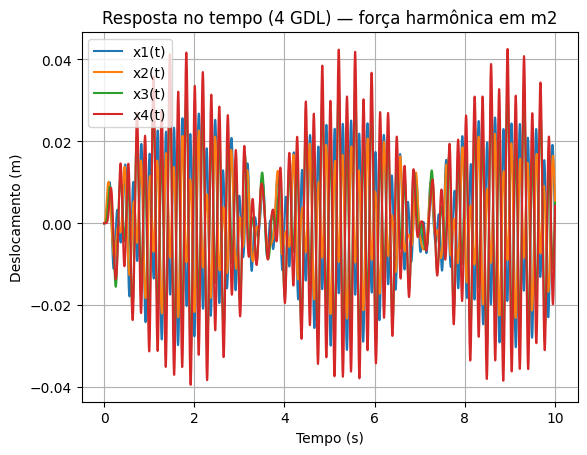

In [10]:
def newmark_beta(M, C, K, f_func, x0, v0, t, beta=1/4, gamma=1/2):
    """Integração Newmark-beta (média constante) para sistema MDOF.
    Retorna x(t), v(t), a(t)."""
    n = M.shape[0]
    dt = t[1] - t[0]
    Nt = len(t)

    x = np.zeros((Nt, n))
    v = np.zeros((Nt, n))
    a = np.zeros((Nt, n))

    x[0] = x0
    v[0] = v0

    # a0 pela equação dinâmica
    a[0] = np.linalg.solve(M, f_func(t[0]) - C@v[0] - K@x[0])

    # matrizes efetivas
    K_eff = K + (gamma/(beta*dt))*C + (1/(beta*dt**2))*M
    K_eff_inv = np.linalg.inv(K_eff)

    for i in range(1, Nt):
        ti = t[i]
        fi = f_func(ti)

        # predição
        x_pred = x[i-1] + dt*v[i-1] + dt**2*(0.5 - beta)*a[i-1]
        v_pred = v[i-1] + dt*(1 - gamma)*a[i-1]

        # força efetiva
        f_eff = fi + M@((1/(beta*dt**2))*x_pred) + C@((gamma/(beta*dt))*x_pred)

        # correção
        x[i] = K_eff_inv @ f_eff
        a[i] = (1/(beta*dt**2))*(x[i] - x_pred)
        v[i] = v_pred + dt*gamma*a[i]

    return x, v, a

# Parâmetros de excitação
F0 = 10.0
wf = omega[1] * 0.95  # excitar perto do 2º modo (um pouco abaixo)
force_dof = 1         # 2ª massa

def f_of_t(tt):
    f = np.zeros(n)
    f[force_dof] = F0*np.sin(wf*tt)
    return f

# Simulação
T = 10.0
fs = 2000
t = np.linspace(0, T, int(T*fs)+1)

x0 = np.zeros(n)
v0 = np.zeros(n)

x, v, a = newmark_beta(M, C, K, f_of_t, x0, v0, t)

# Plot de deslocamentos
plt.figure()
for i in range(n):
    plt.plot(t, x[:, i], label=f"x{i+1}(t)")
plt.xlabel("Tempo (s)")
plt.ylabel("Deslocamento (m)")
plt.title("Resposta no tempo (4 GDL) — força harmônica em m2")
plt.legend()
plt.grid(True)
plt.show()

## 6.6) FFT e estimativa de FRF (via sinais no tempo)

Vamos estimar:
\[
$H_{x_iF}(\omega)\approx \frac{X_i(\omega)}{F(\omega)}$
\]

onde $F(\omega)$ vem da FFT da força aplicada e $X_i(\omega)$ vem da FFT do deslocamento.

> Observação: isso é uma estimativa simples baseada em FFT direta (sem técnicas de média/coerência).  
Em laboratório costuma-se usar estimadores H1/H2 e janelas.


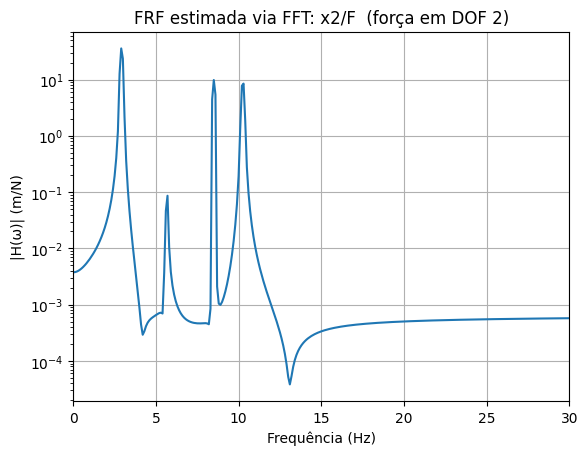

array([ 2.9281,  5.6178,  8.5024, 10.256 ])

In [11]:
def fft_spectrum(sig, fs):
    N = len(sig)
    # janela simples (Hann) para reduzir leakage
    w = np.hanning(N)
    sigw = sig*w

    Sig = np.fft.rfft(sigw)
    freqs = np.fft.rfftfreq(N, d=1/fs)

    # normalização aproximada
    scale = 2/np.sum(w)
    Sig = Sig * scale

    return freqs, Sig

# Sinal da força (no DOF forçado)
f_t = np.array([f_of_t(tt) for tt in t])  # (Nt, n)
f_in = f_t[:, force_dof]

freqs, Fw = fft_spectrum(f_in, fs)

# FRF estimada para cada deslocamento
H = []
for i in range(n):
    _, Xw = fft_spectrum(x[:, i], fs)
    H.append(Xw / (Fw + 1e-12))  # evitar divisão por zero
H = np.array(H)  # (n, nfreq)

# Plot magnitude FRF (em escala log) para um DOF de saída (ex: x2/F)
out_dof = 1
plt.figure()
plt.semilogy(freqs, np.abs(H[out_dof]))
plt.xlim(0, 30)
plt.xlabel("Frequência (Hz)")
plt.ylabel("|H(ω)| (m/N)")
plt.title(f"FRF estimada via FFT: x{out_dof+1}/F  (força em DOF {force_dof+1})")
plt.grid(True)
plt.show()

# Mostrar frequências naturais teóricas para comparação
freq_hz

## 6.7) Interpretação (o que observar)

- Picos da FRF aparecem próximos às **frequências naturais** do sistema.
- A largura do pico está relacionada ao amortecimento.
- Em MDOF, dependendo do par entrada/saída, alguns modos podem aparecer mais fortes ou mais fracos (participação modal).


## 7) (Opcional) Verificação rápida: FRF teórica (receptância) em frequência

A FRF teórica em receptância para um par entrada/saída pode ser obtida por:
\[
$H(\omega)=\left(-\omega^2 M + j\omega C + K\right)^{-1}$
\]

Aqui vamos comparar *aproximadamente* com a estimativa via FFT, para um intervalo de frequências.


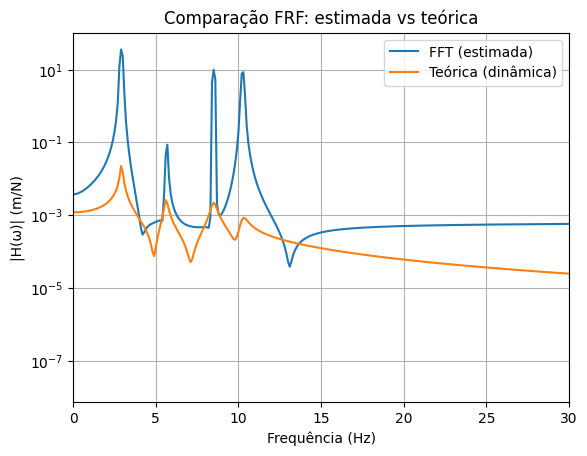

In [12]:
def frf_theoretical(M, C, K, w_list, in_dof, out_dof):
    H = np.zeros(len(w_list), dtype=complex)
    for i, w in enumerate(w_list):
        Z = -w**2*M + 1j*w*C + K
        G = np.linalg.inv(Z)   # receptância (x/F)
        H[i] = G[out_dof, in_dof]
    return H

w_list = 2*np.pi*freqs
Hth = frf_theoretical(M, C, K, w_list, in_dof=force_dof, out_dof=out_dof)

plt.figure()
plt.semilogy(freqs, np.abs(H[out_dof]), label="FFT (estimada)")
plt.semilogy(freqs, np.abs(Hth), label="Teórica (dinâmica)")
plt.xlim(0, 30)
plt.xlabel("Frequência (Hz)")
plt.ylabel("|H(ω)| (m/N)")
plt.title("Comparação FRF: estimada vs teórica")
plt.legend()
plt.grid(True)
plt.show()